## Tools

Tools can be integrated with LLm models to interact with external systems. External Systems can be API's, third party tools.

Whenever a query is asked the model can choose tocall the tool and this query is based on natural language input and this will return an output that matches the tool's schema.

In [23]:
def addTool(a:int,b:int)->int:
    """
    Add a and b
    Args:
       a (int):first int
       b (int):second int
    
       returns :
       int
       
    """
    return a+b

In [24]:
from langgraph.graph import START,END,StateGraph

In [25]:
from langchain_openai import ChatOpenAI

In [26]:
llm=ChatOpenAI(model="gpt-3.5-turbo")

In [27]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [28]:
llm_with_tools=llm.bind_tools([addTool])

In [29]:
from langchain.messages import HumanMessage
llm_with_tools.invoke([HumanMessage(content="what is 2 plus 3")])

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 78, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DNiq6JXB8FJyaFc33Qcy5ONKQ8HO2', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d2b33-4e03-7720-ab01-d2cfa3ac85b0-0', tool_calls=[{'name': 'addTool', 'args': {'a': 2, 'b': 3}, 'id': 'call_MPePlGTFuYMNUmLFfKRJByD5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 18, 'total_tokens': 96, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [30]:
def superbot(state:State):
    return { "messages":[llm.invoke(state['messages'])]}

In [31]:
def superbot_with_tools(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [32]:
graph=StateGraph(State)

# graph.add_node("superbot",superbot)

graph.add_node("superbot_with_tool",superbot_with_tools)

graph.add_edge(START,"superbot_with_tool")
graph.add_edge("superbot_with_tool",END)

graph_builder=graph.compile()

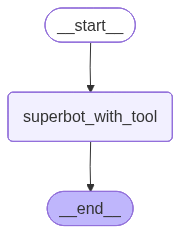

In [33]:
from IPython.display import Image,display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [34]:
graph_builder.invoke({"messages":"what is 2 plus 3"})

{'messages': [HumanMessage(content='what is 2 plus 3', additional_kwargs={}, response_metadata={}, id='99dd75ad-bbe5-4201-a19a-29af34c4d8f9'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 78, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DNiqBQ1EAV1JriO5KRVl8wt6DOt0B', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d2b33-6439-7e52-b1ae-be7d41a30eb9-0', tool_calls=[{'name': 'addTool', 'args': {'a': 2, 'b': 3}, 'id': 'call_QCiCohJybW2oylcrYlL2zmdK', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 18, 'total_tokens': 96,

In [36]:
tools=[addTool]

In [37]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


builder=StateGraph(State)

builder.add_node("llm_tool",superbot_with_tools)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"llm_tool")
builder.add_conditional_edges("llm_tool",tools_condition)

builder.add_edge("llm_tool",END)
builder.add_edge("tools",END)


In [38]:
graph=builder.compile()

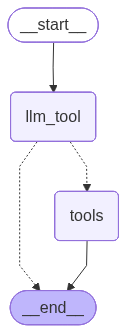

In [39]:
display(Image(graph.get_graph().draw_mermaid_png()))